# Exchange Rate Dataset


Import libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [2]:
INPUT_FILE = "../../data/raw/exchange_rate.csv"
OUTPUT_FILE = "../../data/preprocessed/exchange_rate.csv"
TARGET_COL = "2"

In [3]:
df = pd.read_csv(INPUT_FILE)

if TARGET_COL in df.columns:
    series = df[TARGET_COL]
else:
    series = df.iloc[:, 0]

series = series.interpolate(method="linear", limit=3, limit_direction="both")

output_df = pd.DataFrame({"time_series": series})

output_df.to_csv(OUTPUT_FILE, index=False)
print(f"Processed file saved to {OUTPUT_FILE}")

Processed file saved to ../../data/preprocessed/exchange_rate.csv


## Time Series Plot

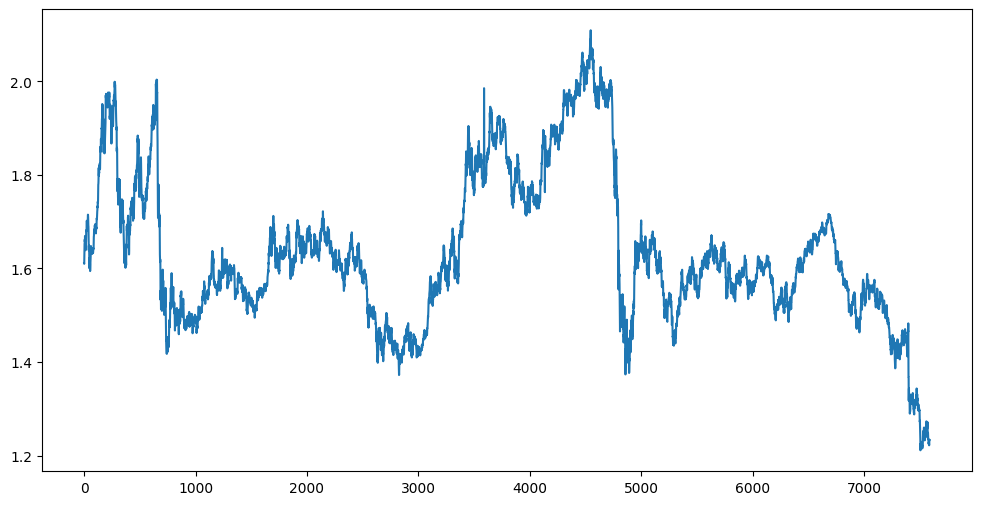

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(output_df.to_numpy()[:100000], label="Time Series")

## ACF


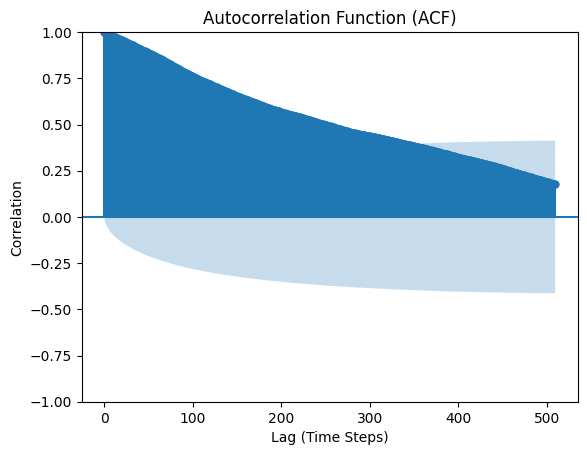

In [5]:
plot_acf(output_df, lags=509, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

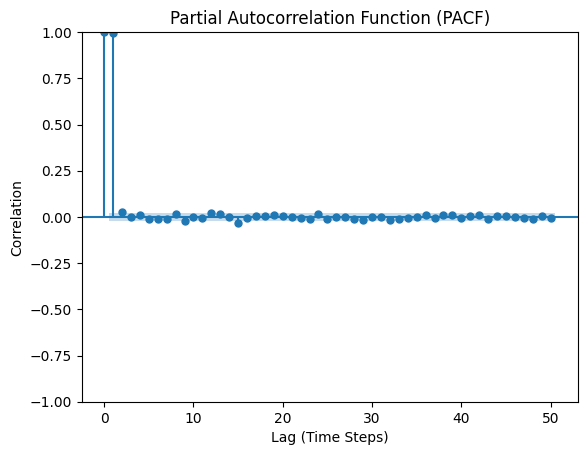

In [ ]:
plot_pacf(output_df, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.5141


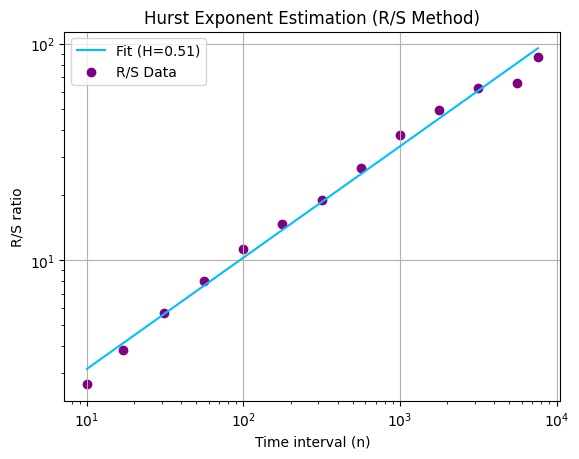

In [22]:
H, c, data = compute_Hc(output_df, kind="price", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()